HOG->PCA->SVM

Crop bounding box → Resize to fixed size → Compute HOG → PCA → SVM

In [1]:
#importing libraries
from pathlib import Path
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from skimage.feature import hog
from tqdm import tqdm

#reproducibility
random.seed(42)
np.random.seed(42)

Download Dataset

In [2]:
import kagglehub

dataset_path = kagglehub.dataset_download('siddharthkumarsah/ships-in-aerial-images')
dataset_path = Path(dataset_path)

print("Downloaded to:", dataset_path)
print("Top-level contents:")
for item in dataset_path.iterdir():
    print(" -", item.name)

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloaded to: C:\Users\user\.cache\kagglehub\datasets\siddharthkumarsah\ships-in-aerial-images\versions\1
Top-level contents:
 - ships-aerial-images


Inspecting Dataset Structure

In [3]:
from pathlib import Path
import os

dataset_path = Path(dataset_path)

print("Downloaded to:", dataset_path)
print("\nTop-level contents:")
for item in sorted(dataset_path.iterdir()):
    print(" -", item)

Downloaded to: C:\Users\user\.cache\kagglehub\datasets\siddharthkumarsah\ships-in-aerial-images\versions\1

Top-level contents:
 - C:\Users\user\.cache\kagglehub\datasets\siddharthkumarsah\ships-in-aerial-images\versions\1\ships-aerial-images


Print Dataset Tree

In [4]:
#function to print tree components
def print_tree(root, max_depth=3, indent=""):
    root = Path(root)
    if max_depth < 0:
        return
    try:
        items = sorted(root.iterdir(), key=lambda p: p.name)
    except Exception:
        return
    
    for item in items[:50]:
        print(indent + item.name)
        if item.is_dir():
            print_tree(item, max_depth - 1, indent + "    ")

print_tree(dataset_path, max_depth=3)

ships-aerial-images
    data.yaml
    test
        images
            02e39612d_jpg.rf.cc5483bb711f080d12b644ff62cf977a.jpg
            04-33800_jpg.rf.c45762dfac8f4c20534434159df41ad2.jpg
            043d8815e_jpg.rf.702fa31e03a8a1c28e5fb63c561ac16e.jpg
            0573861e6_jpg.rf.1fad0872d11e88d7838f88d026832350.jpg
            0__20160905_193458_0c37__-122-34588841807276_37-756417599310865_png.rf.82197eb6853000003827a752a1c02a47.jpg
            0__20161006_004004_0c38__-122-35115763991095_37-7692093023039_png.rf.038e071514696de42fd7fa870bc591b6.jpg
            0__20161102_180658_0e26__-122-32843644745485_37-73923054907409_png.rf.7a1c9584c7dbbfbfae44014464239207.jpg
            0__20161102_180658_0e26__-122-32843644745485_37-73923054907409_png.rf.eaa802fa2bec7639b5fc4c2ea9841a6d.jpg
            0__20161102_180658_0e26__-122-34040514248915_37-748761931300486_png.rf.36a27540d7f3580cbdbc5917ea6dbdc5.jpg
            0__20161102_202001_0c75__-122-33669212065975_37-756528435140176_png.rf.

Folder Finder

In [5]:
#set of image file extensions we want to allow when scanning folders
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def count_images_in_dir(folder):
    folder = Path(folder)
    if not folder.exists() or not folder.is_dir():
        return 0
    return sum(1 for p in folder.rglob("*") if p.suffix.lower() in IMG_EXTS)

def find_split_dirs(base_path, split_name):
   
    base_path = Path(base_path)

    #common exact patterns first
    candidates = [
        (base_path / split_name / "images", base_path / split_name / "labels"),
        (base_path / "images" / split_name, base_path / "labels" / split_name),
    ]

    for img_dir, lbl_dir in candidates:
        if img_dir.exists() and lbl_dir.exists():
            return img_dir, lbl_dir

    #recursive search for folders named exactly split_name
    split_dirs = [p for p in base_path.rglob(split_name) if p.is_dir()]

    for split_dir in split_dirs:
        img_dir = split_dir / "images"
        lbl_dir = split_dir / "labels"
        if img_dir.exists() and lbl_dir.exists():
            return img_dir, lbl_dir

    #recursive search for any images/labels pair with parent name == split_name
    all_image_dirs = [p for p in base_path.rglob("images") if p.is_dir()]
    all_label_dirs = [p for p in base_path.rglob("labels") if p.is_dir()]

    for img_dir in all_image_dirs:
        if img_dir.parent.name.lower() == split_name.lower():
            sibling_lbl = img_dir.parent / "labels"
            if sibling_lbl.exists():
                return img_dir, sibling_lbl

    for lbl_dir in all_label_dirs:
        if lbl_dir.parent.name.lower() == split_name.lower():
            sibling_img = lbl_dir.parent / "images"
            if sibling_img.exists():
                return sibling_img, lbl_dir

    return None, None

train_img_dir, train_lbl_dir = find_split_dirs(dataset_path, "train")
valid_img_dir, valid_lbl_dir = find_split_dirs(dataset_path, "valid")
test_img_dir, test_lbl_dir = find_split_dirs(dataset_path, "test")

print("train_img_dir:", train_img_dir)
print("train_lbl_dir:", train_lbl_dir)
print("valid_img_dir:", valid_img_dir)
print("valid_lbl_dir:", valid_lbl_dir)
print("test_img_dir :", test_img_dir)
print("test_lbl_dir :", test_lbl_dir)

train_img_dir: C:\Users\user\.cache\kagglehub\datasets\siddharthkumarsah\ships-in-aerial-images\versions\1\ships-aerial-images\train\images
train_lbl_dir: C:\Users\user\.cache\kagglehub\datasets\siddharthkumarsah\ships-in-aerial-images\versions\1\ships-aerial-images\train\labels
valid_img_dir: C:\Users\user\.cache\kagglehub\datasets\siddharthkumarsah\ships-in-aerial-images\versions\1\ships-aerial-images\valid\images
valid_lbl_dir: C:\Users\user\.cache\kagglehub\datasets\siddharthkumarsah\ships-in-aerial-images\versions\1\ships-aerial-images\valid\labels
test_img_dir : C:\Users\user\.cache\kagglehub\datasets\siddharthkumarsah\ships-in-aerial-images\versions\1\ships-aerial-images\test\images
test_lbl_dir : C:\Users\user\.cache\kagglehub\datasets\siddharthkumarsah\ships-in-aerial-images\versions\1\ships-aerial-images\test\labels


Validating Split Folders

In [6]:
def validate_split(img_dir, lbl_dir, split_name):
    if img_dir is None or lbl_dir is None:
        print(f"{split_name}: NOT FOUND")
        return False
    
    n_imgs = count_images_in_dir(img_dir)
    n_lbls = len(list(Path(lbl_dir).glob("*.txt")))
    
    print(f"{split_name}:")
    print("  images folder:", img_dir)
    print("  labels folder:", lbl_dir)
    print("  image count  :", n_imgs)
    print("  label count  :", n_lbls)
    return n_imgs > 0 and n_lbls > 0

ok_train = validate_split(train_img_dir, train_lbl_dir, "TRAIN")
ok_valid = validate_split(valid_img_dir, valid_lbl_dir, "VALID")
ok_test  = validate_split(test_img_dir, test_lbl_dir, "TEST")

if not (ok_train and ok_valid and ok_test):
    raise RuntimeError("One or more dataset splits were not found correctly. Check the printed tree above.")

TRAIN:
  images folder: C:\Users\user\.cache\kagglehub\datasets\siddharthkumarsah\ships-in-aerial-images\versions\1\ships-aerial-images\train\images
  labels folder: C:\Users\user\.cache\kagglehub\datasets\siddharthkumarsah\ships-in-aerial-images\versions\1\ships-aerial-images\train\labels
  image count  : 9697
  label count  : 9697
VALID:
  images folder: C:\Users\user\.cache\kagglehub\datasets\siddharthkumarsah\ships-in-aerial-images\versions\1\ships-aerial-images\valid\images
  labels folder: C:\Users\user\.cache\kagglehub\datasets\siddharthkumarsah\ships-in-aerial-images\versions\1\ships-aerial-images\valid\labels
  image count  : 2165
  label count  : 2165
TEST:
  images folder: C:\Users\user\.cache\kagglehub\datasets\siddharthkumarsah\ships-in-aerial-images\versions\1\ships-aerial-images\test\images
  labels folder: C:\Users\user\.cache\kagglehub\datasets\siddharthkumarsah\ships-in-aerial-images\versions\1\ships-aerial-images\test\labels
  image count  : 1573
  label count  : 157

Utility Functions

In [7]:

def list_images(img_dir):
    #convert folder path to a Path object
    img_dir = Path(img_dir)
    #if the folder does not exist, return an empty list
    if not img_dir.exists():
        return []
    #recursively collect all files that have a valid image extension
    return sorted([p for p in img_dir.rglob("*") if p.suffix.lower() in IMG_EXTS])

def corresponding_label_path(img_path, label_dir):
    #each image should have a matching YOLO label file with the same file name stem
    return Path(label_dir) / f"{Path(img_path).stem}.txt"

def read_yolo_labels(label_path):
    #store all bounding boxes found in the label file
    boxes = []
    label_path = Path(label_path)

    if not label_path.exists():
        return boxes

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id, xc, yc, w, h = map(float, parts)
            boxes.append((int(cls_id), xc, yc, w, h))
    return boxes

def yolo_to_pixel_box(box, img_w, img_h):
    #convert one YOLO box from normalized coordinates to pixel coordinates
    cls_id, xc, yc, bw, bh = box

    #convert normalized center position and box size into pixel units
    x_center = xc * img_w
    y_center = yc * img_h
    box_w = bw * img_w
    box_h = bh * img_h

    #convert center-width-height form into corner coordinates
    x1 = int(x_center - box_w / 2)
    y1 = int(y_center - box_h / 2)
    x2 = int(x_center + box_w / 2)
    y2 = int(y_center + box_h / 2)

    #clip box coordinates so they stay inside the image boundaries
    x1 = max(0, min(x1, img_w - 1))
    y1 = max(0, min(y1, img_h - 1))
    x2 = max(0, min(x2, img_w))
    y2 = max(0, min(y2, img_h))

    return x1, y1, x2, y2

def crop_from_box(img, box):
    #extract a crop from the image using pixel box coordinates
    x1, y1, x2, y2 = box
    #ignore invalid boxes
    if x2 <= x1 or y2 <= y1:
        return None
    return img[y1:y2, x1:x2]

def resize_crop(crop, size=(64, 64)):
    #resize a crop to a fixed size so all inputs are consistent for HOG
    if crop is None or crop.size == 0:
        return None
    return cv2.resize(crop, size, interpolation=cv2.INTER_AREA)

def compute_iou(boxA, boxB):
    #intersection-over-union between two bounding boxes
    #find coordinates of the overlap region so neg crops don't overlap with ships
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    #compute overlap area
    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter_area = inter_w * inter_h

    #compute area of each box
    areaA = max(0, boxA[2] - boxA[0]) * max(0, boxA[3] - boxA[1])
    areaB = max(0, boxB[2] - boxB[0]) * max(0, boxB[3] - boxB[1])

    #compute union area
    union = areaA + areaB - inter_area
    if union <= 0:
        return 0.0
    #return IoU value
    return inter_area / union

Visualize one image and its boxes

Number of training images: 9697
Sample image: 00c571edd_jpg.rf.0f6f720912e0234d271a3b7fcdda6135.jpg
Sample label: 00c571edd_jpg.rf.0f6f720912e0234d271a3b7fcdda6135.txt | exists: True


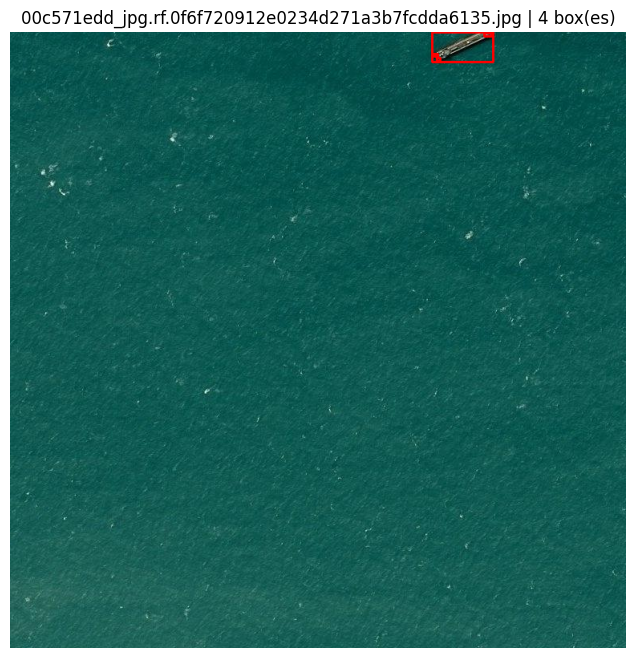

In [8]:
#get a list of all training images
train_images = list_images(train_img_dir)
print("Number of training images:", len(train_images))

#stop if no training images were found
if len(train_images) == 0:
    raise RuntimeError("No training images found.")

#pick the first image in the training set as a sample
sample_img_path = train_images[0]
#find its matching YOLO label file
sample_lbl_path = corresponding_label_path(sample_img_path, train_lbl_dir)

print("Sample image:", sample_img_path.name)
print("Sample label:", sample_lbl_path.name, "| exists:", sample_lbl_path.exists())

#read the image with OpenCV
img_bgr = cv2.imread(str(sample_img_path))
if img_bgr is None:
    raise RuntimeError(f"Could not read image: {sample_img_path}")

#convert from BGR to RGB so matplotlib displays it correctly
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w = img_rgb.shape[:2]

#read YOLO bounding boxes from the label file
boxes = read_yolo_labels(sample_lbl_path)
#convert each YOLO box into pixel coordinates
pixel_boxes = [yolo_to_pixel_box(b, w, h) for b in boxes]

#copy of the image so we can draw boxes on it
img_vis = img_rgb.copy()
for (x1, y1, x2, y2) in pixel_boxes:
    cv2.rectangle(img_vis, (x1, y1), (x2, y2), (255, 0, 0), 2)
    
#display the image with its ship bounding boxes
plt.figure(figsize=(8, 8))
plt.imshow(img_vis)
plt.title(f"{sample_img_path.name} | {len(pixel_boxes)} box(es)")
plt.axis("off")
plt.show()

Generating positive and negative crops

In [9]:

#fixed size used for all cropped patches
FIXED_SIZE = (64, 64)
#number of background crops to generate per image
NEG_PER_IMAGE = 2
#maximum number of attempts to find a valid negative crop
MAX_NEG_ATTEMPTS = 40

def generate_negative_box(img_w, img_h, gt_boxes, min_size=24, max_size=128, iou_thresh=0.05):
    for _ in range(MAX_NEG_ATTEMPTS):
        bw = random.randint(min_size, min(max_size, img_w - 1))
        bh = random.randint(min_size, min(max_size, img_h - 1))

        if bw >= img_w or bh >= img_h:
            continue

        x1 = random.randint(0, img_w - bw)
        y1 = random.randint(0, img_h - bh)
        x2 = x1 + bw
        y2 = y1 + bh

        candidate = (x1, y1, x2, y2)

        if len(gt_boxes) == 0:
            return candidate

        max_iou = max(compute_iou(candidate, gt) for gt in gt_boxes)
        if max_iou < iou_thresh:
            return candidate

    return None

def generate_negative_box(img_w, img_h, gt_boxes, min_size=24, max_size=128, iou_thresh=0.05):
    #ty multiple times to generate a random background crop
    #that does not overlap too much with any ship bounding box
    for _ in range(MAX_NEG_ATTEMPTS):
        
        #randomly choose width and height of the candidate negative crop
        bw = random.randint(min_size, min(max_size, img_w - 1))
        bh = random.randint(min_size, min(max_size, img_h - 1))

        #skip if crop is too large for the image
        if bw >= img_w or bh >= img_h:
            continue

        #randomly choose the top-left corner of the crop
        x1 = random.randint(0, img_w - bw)
        y1 = random.randint(0, img_h - bh)
        x2 = x1 + bw
        y2 = y1 + bh

        candidate = (x1, y1, x2, y2)

        #if there are no ground truth boxes, any crop is acceptable
        if len(gt_boxes) == 0:
            return candidate

        #measure the overlap with all ship boxes
        max_iou = max(compute_iou(candidate, gt) for gt in gt_boxes)

        #accept this crop if overlap is very small
        if max_iou < iou_thresh:
            return candidate

    #if no valid crop is found after all attempts, return None
    return None

def extract_dataset_crops(img_dir, lbl_dir, fixed_size=(64, 64), neg_per_image=2, max_images=None):
    #lists that will store image crops and their labels
    X_crops = []
    y = []

    #get all images from this dataset split
    image_paths = list_images(img_dir)

    #optionally limit how many images are used
    if max_images is not None:
        image_paths = image_paths[:max_images]

    #loop through each image in the split
    for img_path in tqdm(image_paths, desc=f"Processing {Path(img_dir).name}"):
        lbl_path = corresponding_label_path(img_path, lbl_dir)

        #read image
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            continue

        #convert to RGB for consistency
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_h, img_w = img_rgb.shape[:2]

        #read YOLO labels and convert them to pixel boxes
        yolo_boxes = read_yolo_labels(lbl_path)
        gt_boxes = [yolo_to_pixel_box(b, img_w, img_h) for b in yolo_boxes]

        #positive samples
        for box in gt_boxes:
            crop = crop_from_box(img_rgb, box)
            crop = resize_crop(crop, fixed_size)

            #add valid positive crop
            if crop is not None:
                X_crops.append(crop)
                y.append(1)
                
        #negative samples
        for _ in range(neg_per_image):
            neg_box = generate_negative_box(img_w, img_h, gt_boxes)
            if neg_box is None:
                continue

            crop = crop_from_box(img_rgb, neg_box)
            crop = resize_crop(crop, fixed_size)

            #add valid negative crop
            if crop is not None:
                X_crops.append(crop)
                y.append(0)

    return X_crops, y

Building datasets for train, valid, and test

In [10]:
#build train/validation/test crop datasets
X_train_crops, y_train = extract_dataset_crops(train_img_dir, train_lbl_dir, fixed_size=FIXED_SIZE, neg_per_image=NEG_PER_IMAGE)
X_valid_crops, y_valid = extract_dataset_crops(valid_img_dir, valid_lbl_dir, fixed_size=FIXED_SIZE, neg_per_image=NEG_PER_IMAGE)
X_test_crops,  y_test  = extract_dataset_crops(test_img_dir,  test_lbl_dir,  fixed_size=FIXED_SIZE, neg_per_image=NEG_PER_IMAGE)

#print how many total samples, positives, and negative# were created in each split
print("Train samples:", len(X_train_crops), "| positives:", sum(y_train), "| negatives:", len(y_train) - sum(y_train))
print("Valid samples:", len(X_valid_crops), "| positives:", sum(y_valid), "| negatives:", len(y_valid) - sum(y_valid))
print("Test samples :", len(X_test_crops),  "| positives:", sum(y_test),  "| negatives:", len(y_test) - sum(y_test))

Processing images: 100%|██████████| 1573/1573 [00:42<00:00, 37.06it/s]


Train samples: 37849 | positives: 18499 | negatives: 19350
Valid samples: 7817 | positives: 3499 | negatives: 4318
Test samples : 5829 | positives: 2685 | negatives: 3144


Showing Example Crops

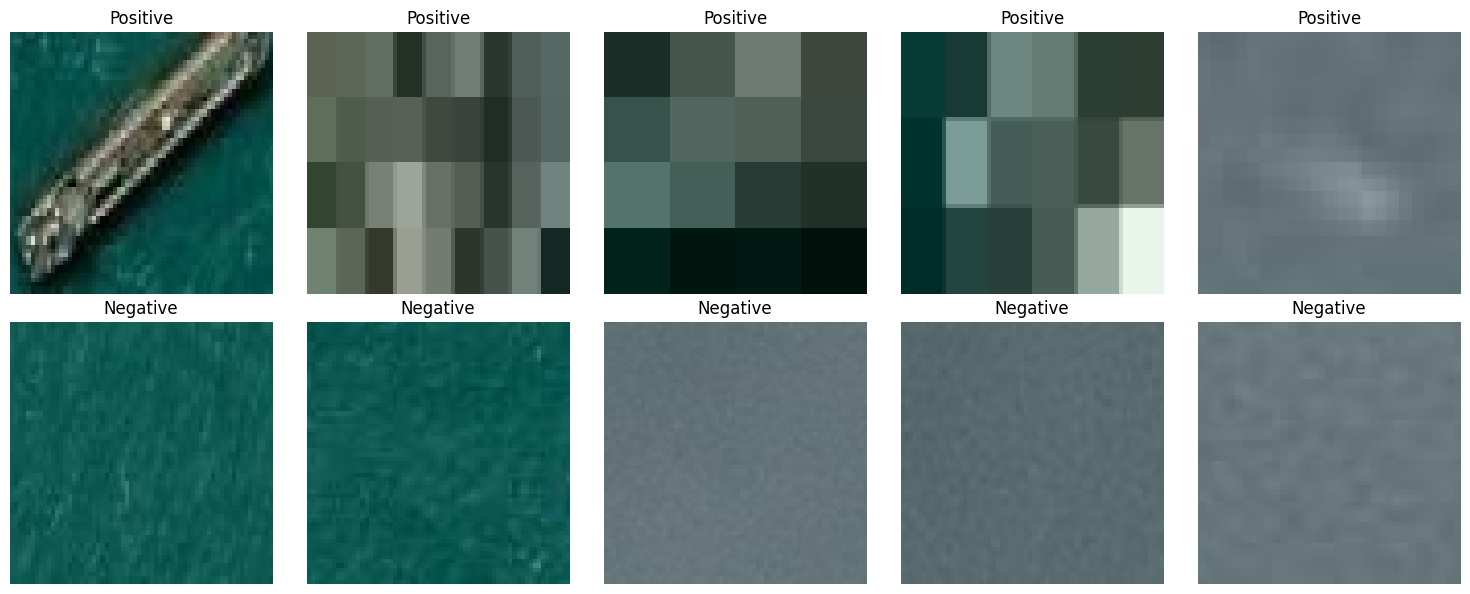

In [11]:
def show_examples(crops, labels, n=5):
    #find indices of positive and negative examples
    pos_idxs = [i for i, lab in enumerate(labels) if lab == 1][:n]
    neg_idxs = [i for i, lab in enumerate(labels) if lab == 0][:n]

    #display as many pairs as we have available
    total = min(n, len(pos_idxs), len(neg_idxs))
    if total == 0:
        print("Not enough crops to display.")
        return

    plt.figure(figsize=(15, 6))
    #show positive ship crops in the top row
    for i, idx in enumerate(pos_idxs[:total]):
        plt.subplot(2, total, i + 1)
        plt.imshow(crops[idx])
        plt.title("Positive")
        plt.axis("off")
    #show negative background crops in the bottom row
    for i, idx in enumerate(neg_idxs[:total]):
        plt.subplot(2, total, total + i + 1)
        plt.imshow(crops[idx])
        plt.title("Negative")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
#display a few sample positive and negative crops from training data
show_examples(X_train_crops, y_train, n=5)

Computing Hog Fetures

In [12]:
#convert image crops into HOG feature vectors
def compute_hog_features(crops):
    features = []

    for crop in tqdm(crops, desc="Computing HOG"):
        #convert crop to grayscale
        gray = cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY)

        #extract HOG features
        feat = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm="L2-Hys",
            transform_sqrt=True,
            feature_vector=True #1D vector
            #store descriptor as one feature vector

        )
        features.append(feat)

    return np.array(features)

#compute HOG features for all three splits
X_train_hog = compute_hog_features(X_train_crops)
X_valid_hog = compute_hog_features(X_valid_crops)
X_test_hog  = compute_hog_features(X_test_crops)

#print feature matrix shapes
print("HOG train shape:", X_train_hog.shape)
print("HOG valid shape:", X_valid_hog.shape)
print("HOG test shape :", X_test_hog.shape)

Computing HOG: 100%|██████████| 5829/5829 [00:18<00:00, 321.91it/s]

HOG train shape: (37849, 1764)
HOG valid shape: (7817, 1764)
HOG test shape : (5829, 1764)


PCA

In [13]:
#reduce HOG feature dimension using PCA

#keep enough principal components to preserve 95% of the variance
pca = PCA(n_components=0.95, svd_solver="full", random_state=42)

#fit PCA on the training data only
#then transform validation and test using the same PCA model
X_train_pca = pca.fit_transform(X_train_hog)
X_valid_pca = pca.transform(X_valid_hog)
X_test_pca  = pca.transform(X_test_hog)

#showing how much the feature dimension shrank
print("Original HOG dimension:", X_train_hog.shape[1])
print("Reduced PCA dimension :", X_train_pca.shape[1])
print("Explained variance sum:", pca.explained_variance_ratio_.sum())

Original HOG dimension: 1764
Reduced PCA dimension : 474
Explained variance sum: 0.9501944143362077


Training SVM

In [14]:
#training the classifier
from sklearn.svm import LinearSVC
import time

start = time.time()

#this learns to separate: label 1 = ship or label 0 = background
svm = LinearSVC(
    C=1.0,#regularization strength
    class_weight="balanced",
    max_iter=10000,#allow enough iterations to converge
    random_state=42
)
#fit the classifier on the PCA-transformed training features
svm.fit(X_train_pca, y_train)

end = time.time()
print(f"SVM training complete in {end - start:.2f} seconds.")

SVM training complete in 5.87 seconds.


Validation Results

In [15]:
#evaluate on validation set
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#predict ship/background labels for validation crops
y_valid_pred = svm.predict(X_valid_pca)

#print evaluation metrics
print("Validation Accuracy:", accuracy_score(y_valid, y_valid_pred))
print("\nValidation Confusion Matrix:")
print(confusion_matrix(y_valid, y_valid_pred))
print("\nValidation Classification Report:")
print(classification_report(y_valid, y_valid_pred, digits=4))

Validation Accuracy: 0.8849942433158501

Validation Confusion Matrix:
[[3836  482]
 [ 417 3082]]

Validation Classification Report:
              precision    recall  f1-score   support

           0     0.9020    0.8884    0.8951      4318
           1     0.8648    0.8808    0.8727      3499

    accuracy                         0.8850      7817
   macro avg     0.8834    0.8846    0.8839      7817
weighted avg     0.8853    0.8850    0.8851      7817



Test Results

In [16]:
#evaluate on test set

#predict labels for test crops
y_test_pred = svm.predict(X_test_pca)

#print final test metrics
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nTest Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy: 0.8896894836164008

Test Confusion Matrix:
[[2811  333]
 [ 310 2375]]

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9007    0.8941    0.8974      3144
           1     0.8770    0.8845    0.8808      2685

    accuracy                         0.8897      5829
   macro avg     0.8889    0.8893    0.8891      5829
weighted avg     0.8898    0.8897    0.8897      5829



Show crop predictions

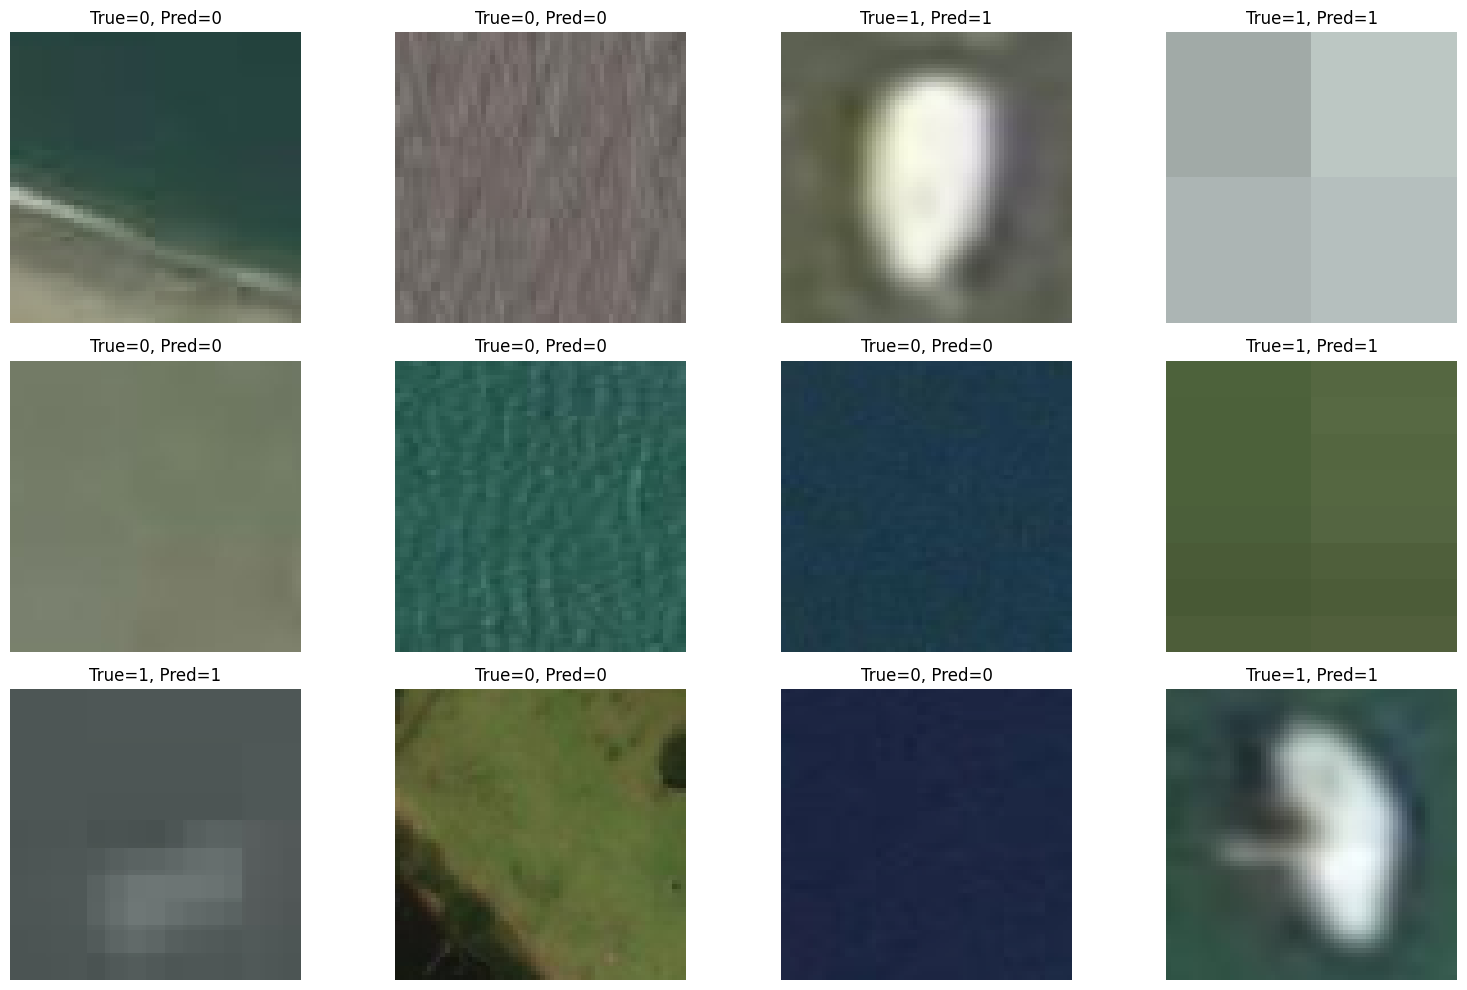

In [ ]:
#visualize a few test crop predictions

#display random crops from the test set with: ground truth label and predicted label  
def show_pred_examples(crops, true_labels, pred_labels, n=12):
    if len(crops) == 0:
        print("No crops available.")
        return

    #randomly choose indices to display
    idxs = np.random.choice(len(crops), size=min(n, len(crops)), replace=False)

    plt.figure(figsize=(16, 10))
    for i, idx in enumerate(idxs):
        plt.subplot(3, 4, i + 1)
        plt.imshow(crops[idx])
        plt.title(f"True={true_labels[idx]}, Pred={pred_labels[idx]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_pred_examples(X_test_crops, y_test, y_test_pred, n=12)

Sliding Window

In [ ]:
#generate sliding window patches across an image
def sliding_windows(image, window_size=(64, 64), stride=32):
    
    h, w = image.shape[:2]
    win_w, win_h = window_size

    for y in range(0, h - win_h + 1, stride):
        for x in range(0, w - win_w + 1, stride):
            patch = image[y:y + win_h, x:x + win_w]
            yield (x, y, x + win_w, y + win_h), patch

Score one window using HOG + PCA + trained SVM

In [ ]:

#convert one RGB patch into a single HOG feature vector
def extract_hog_feature_from_patch(patch):
    
    gray = cv2.cvtColor(patch, cv2.COLOR_RGB2GRAY)

    feat = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        transform_sqrt=True,
        feature_vector=True
    )

    return feat.reshape(1, -1)
#compute the classifier score for one patch
def score_patch_with_model(patch, pca_model, svm_model):
    
    feat = extract_hog_feature_from_patch(patch)
    feat_pca = pca_model.transform(feat)

    pred_label = svm_model.predict(feat_pca)[0]

    #linearSVC supports decision_function which gives a real-valued score
    score = svm_model.decision_function(feat_pca)[0]

    return pred_label, score

Non-Maximum Suppression (NMS)

In [ ]:

def non_max_suppression(boxes, scores, iou_thresh=0.2):
   
    if len(boxes) == 0:
        return [], []

    boxes = np.array(boxes, dtype=np.float32)
    scores = np.array(scores, dtype=np.float32)

    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]

    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]#sort by descending score

    keep = []

    while len(order) > 0:
        i = order[0]
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)
        inter = w * h

        union = areas[i] + areas[order[1:]] - inter
        ious = np.where(union > 0, inter / union, 0)

        remaining = np.where(ious < iou_thresh)[0]
        order = order[remaining + 1]

    kept_boxes = [tuple(boxes[i].astype(int)) for i in keep]
    kept_scores = [float(scores[i]) for i in keep]

    return kept_boxes, kept_scores

Run sliding window detection on one image

In [ ]:

#run sliding window detection on a full image
#slide fixed-size windows across image
def detect_ships_in_image(
    image_rgb,
    pca_model,
    svm_model,
    window_size=(64, 64),
    stride=32,
    score_thresh=0.5,
    nms_iou_thresh=0.2
):
 
    raw_boxes = []
    raw_scores = []

    for box, patch in sliding_windows(image_rgb, window_size=window_size, stride=stride):
        pred_label, score = score_patch_with_model(patch, pca_model, svm_model)

        #keep only predicted positive windows with enough score
        if pred_label == 1 and score >= score_thresh:
            raw_boxes.append(box)
            raw_scores.append(score)
            
    #apply NMS to reduce duplicates
    final_boxes, final_scores = non_max_suppression(raw_boxes, raw_scores, iou_thresh=nms_iou_thresh)
    return final_boxes, final_scores

Visualize detections on one test image

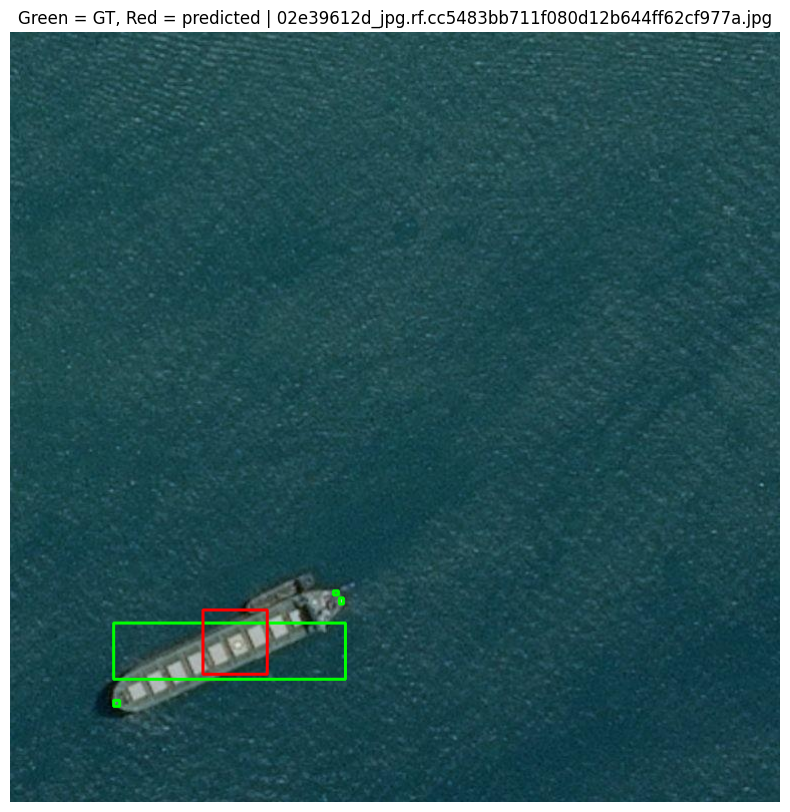

Ground-truth boxes: 4
Predicted boxes after NMS: 1


In [ ]:

#read the ground-truth YOLO boxes for one image and convert to pixel boxes
def get_gt_boxes_for_image(img_path, lbl_dir):
   
    lbl_path = corresponding_label_path(img_path, lbl_dir)

    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    yolo_boxes = read_yolo_labels(lbl_path)
    gt_boxes = [yolo_to_pixel_box(b, w, h) for b in yolo_boxes]

    return img_rgb, gt_boxes

#pick one test image
test_images = list_images(test_img_dir)
sample_test_img = test_images[0]

img_rgb, gt_boxes = get_gt_boxes_for_image(sample_test_img, test_lbl_dir)

pred_boxes, pred_scores = detect_ships_in_image(
    img_rgb,
    pca,
    svm,
    window_size=FIXED_SIZE,
    stride=32,
    score_thresh=0.5,
    nms_iou_thresh=0.2
)

#draw GT in green and predictions in red
img_vis = img_rgb.copy()

for (x1, y1, x2, y2) in gt_boxes:
    cv2.rectangle(img_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)

for (x1, y1, x2, y2) in pred_boxes:
    cv2.rectangle(img_vis, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.figure(figsize=(10, 10))
plt.imshow(img_vis)
plt.title(f"Green = GT, Red = predicted | {sample_test_img.name}")
plt.axis("off")
plt.show()

print("Ground-truth boxes:", len(gt_boxes))
print("Predicted boxes after NMS:", len(pred_boxes))

Match predicted boxes to GT using IoU

In [ ]:
#match predicted boxes to GT using IoU
def match_predictions_to_ground_truth(pred_boxes, gt_boxes, iou_match_thresh=0.2):
   
    matched_gt = set()
    tp = 0
    fp = 0
    matched_ious = []

    for pred_box in pred_boxes:
        best_iou = 0
        best_gt_idx = -1

        for gt_idx, gt_box in enumerate(gt_boxes):
            if gt_idx in matched_gt:
                continue

            iou = compute_iou(pred_box, gt_box)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx

        if best_iou >= iou_match_thresh:
            tp += 1
            matched_gt.add(best_gt_idx)
            matched_ious.append(best_iou)
        else:
            fp += 1

    fn = len(gt_boxes) - len(matched_gt)

    return tp, fp, fn, matched_ious

Evaluate full-image detection on entire test dataset

In [ ]:

def evaluate_detection_on_test_set(
    test_img_dir,
    test_lbl_dir,
    pca_model,
    svm_model,
    window_size=(64, 64),
    stride=32,
    score_thresh=0.5,
    nms_iou_thresh=0.2,
    iou_match_thresh=0.2,
    max_images=None
):
 
    image_paths = list_images(test_img_dir)
    if max_images is not None:
        image_paths = image_paths[:max_images]

    total_tp = 0
    total_fp = 0
    total_fn = 0
    all_matched_ious = []

    image_correct = 0
    image_total = 0

    for img_path in tqdm(image_paths, desc="Evaluating sliding-window detector"):
        img_rgb, gt_boxes = get_gt_boxes_for_image(img_path, test_lbl_dir)

        pred_boxes, pred_scores = detect_ships_in_image(
            img_rgb,
            pca_model,
            svm_model,
            window_size=window_size,
            stride=stride,
            score_thresh=score_thresh,
            nms_iou_thresh=nms_iou_thresh
        )

        tp, fp, fn, matched_ious = match_predictions_to_ground_truth(
            pred_boxes,
            gt_boxes,
            iou_match_thresh=iou_match_thresh
        )

        total_tp += tp
        total_fp += fp
        total_fn += fn
        all_matched_ious.extend(matched_ious)

        #optional image-level "ship present vs no ship predicted"
        gt_present = len(gt_boxes) > 0
        pred_present = len(pred_boxes) > 0
        if gt_present == pred_present:
            image_correct += 1
        image_total += 1

    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    #this is a simple detection-style accuracy, not the standard object detection metric
    detection_accuracy = total_tp / (total_tp + total_fp + total_fn) if (total_tp + total_fp + total_fn) > 0 else 0.0

    mean_iou = np.mean(all_matched_ious) if len(all_matched_ious) > 0 else 0.0
    image_accuracy = image_correct / image_total if image_total > 0 else 0.0

    results = {
        "TP": total_tp,
        "FP": total_fp,
        "FN": total_fn,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Detection Accuracy": detection_accuracy,
        "Mean IoU": mean_iou,
        "Image-level Accuracy": image_accuracy,
        "Matched Detections": len(all_matched_ious),
        "Images Evaluated": image_total
    }

    return results

In [ ]:
#run detection evaluation

results = evaluate_detection_on_test_set(
    test_img_dir=test_img_dir,
    test_lbl_dir=test_lbl_dir,
    pca_model=pca,
    svm_model=svm,
    window_size=FIXED_SIZE,# should match your crop size, e.g. (64,64)
    stride=32,# smaller stride = more windows, slower but better coverage
    score_thresh=0.5,# raise this if too many false positives
    nms_iou_thresh=0.2,
    iou_match_thresh=0.2,
    max_images=1573# start small for debugging, then remove or increase
)

for k, v in results.items():
    print(f"{k}: {v}")

Evaluating sliding-window detector:   0%|          | 0/1573 [00:00<?, ?it/s]

Evaluating sliding-window detector: 100%|██████████| 1573/1573 [48:14<00:00,  1.84s/it]  

TP: 350
FP: 11695
FN: 2454
Precision: 0.029057700290577002
Recall: 0.12482168330955777
F1: 0.047141221631086264
Detection Accuracy: 0.024139595834195463
Mean IoU: 0.3476672946375161
Image-level Accuracy: 0.7101080737444374
Matched Detections: 350
Images Evaluated: 1573


Finding mAP values

In [ ]:
#compute AP at a single IoU threshold

def compute_ap_at_iou(all_detections, all_gts, iou_thresh=0.5):

    #flatten detections across all images
    dets = []
    total_gt = 0

    for img_idx, (preds, gts) in enumerate(zip(all_detections, all_gts)):
        total_gt += len(gts)
        for (box, score) in preds:
            dets.append((img_idx, box, score))

    if total_gt == 0 or len(dets) == 0:
        return 0.0

    #sort detections by descending confidence
    dets.sort(key=lambda x: x[2], reverse=True)

    tp = np.zeros(len(dets))
    fp = np.zeros(len(dets))

    #track which GT boxes are already matched
    matched = {i: set() for i in range(len(all_gts))}

    for i, (img_idx, pred_box, score) in enumerate(dets):
        gts = all_gts[img_idx]

        best_iou = 0
        best_gt_idx = -1

        for j, gt_box in enumerate(gts):
            iou = compute_iou(pred_box, gt_box)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = j

        if best_iou >= iou_thresh and best_gt_idx not in matched[img_idx]:
            tp[i] = 1
            matched[img_idx].add(best_gt_idx)
        else:
            fp[i] = 1

    #cumulative sums
    tp_cum = np.cumsum(tp)
    fp_cum = np.cumsum(fp)

    recalls = tp_cum / total_gt
    precisions = tp_cum / (tp_cum + fp_cum + 1e-8)

    #compute AP using numerical integration
    ap = np.trapz(precisions, recalls)

    return ap

In [ ]:

#gather detections for test set
def collect_detections(
    test_img_dir,
    test_lbl_dir,
    pca_model,
    svm_model,
    window_size=(64,64),
    stride=32,
    score_thresh=0.5,
    nms_iou_thresh=0.2,
    max_images=None
):
    image_paths = list_images(test_img_dir)
    if max_images is not None:
        image_paths = image_paths[:max_images]

    all_detections = []
    all_gts = []

    for img_path in tqdm(image_paths, desc="Collecting detections"):
        img_rgb, gt_boxes = get_gt_boxes_for_image(img_path, test_lbl_dir)

        pred_boxes, pred_scores = detect_ships_in_image(
            img_rgb,
            pca_model,
            svm_model,
            window_size=window_size,
            stride=stride,
            score_thresh=score_thresh,
            nms_iou_thresh=nms_iou_thresh
        )

        preds = list(zip(pred_boxes, pred_scores))

        all_detections.append(preds)
        all_gts.append(gt_boxes)

    return all_detections, all_gts

Computing mAP metrics

In [ ]:
#compute mAP metrics
all_detections, all_gts = collect_detections(
    test_img_dir=test_img_dir,
    test_lbl_dir=test_lbl_dir,
    pca_model=pca,
    svm_model=svm,
    window_size=FIXED_SIZE,
    stride=32,
    score_thresh=0.5,
    nms_iou_thresh=0.2,
    max_images=1573
)

#mAP@0.5
map50 = compute_ap_at_iou(all_detections, all_gts, iou_thresh=0.5)
print(f"mAP@0.5: {map50:.4f}")

#mAP@[0.5:0.95]
ious = np.arange(0.5, 1.0, 0.05)
aps = []

for iou_t in ious:
    ap = compute_ap_at_iou(all_detections, all_gts, iou_thresh=iou_t)
    aps.append(ap)

map50_95 = np.mean(aps)
print(f"mAP@0.5:0.95: {map50_95:.4f}")

mAP@0.5: 0.0007
mAP@0.5:0.95: 0.0001
